CARGANDO BASE DE DATOS
✅ Base cargada: 6,358 observaciones
✅ Variables: 18

1. CREANDO VARIABLES DERIVADAS
✅ Variables derivadas creadas
   - mujer: 1,995 (31.4%)
   - urbano: 3,849 (60.5%)
   - edad_cuadrado: media 3004
   - interaccion (usa_billetera × informal): 482.0 (7.6%)

2. TABLA C. USUARIOS VS NO USUARIOS DE BILLETERA (USO)
Variable                            |   Usuarios |  No usuarios |     Dif. |  Valor p
---------------------------------------------------------------------------
Entrada al crédito formal (2025)    |     0.2041 |       0.0747 |  +0.1294 |   0.0000 ***
Trabajador informal (2024)          |     0.5528 |       0.8283 |  -0.2755 |   0.0000 ***
Edad (2024)                         |    42.8440 |      54.4377 | -11.5936 |   0.0000 ***
Mujer (2024)                        |     0.3888 |       0.3019 |  +0.0869 |   0.0000 ***
Nivel educativo (1-12) (2024)       |     6.8647 |       4.7871 |  +2.0776 |   0.0000 ***
Urbano (2024)                       |     0.9025 |   

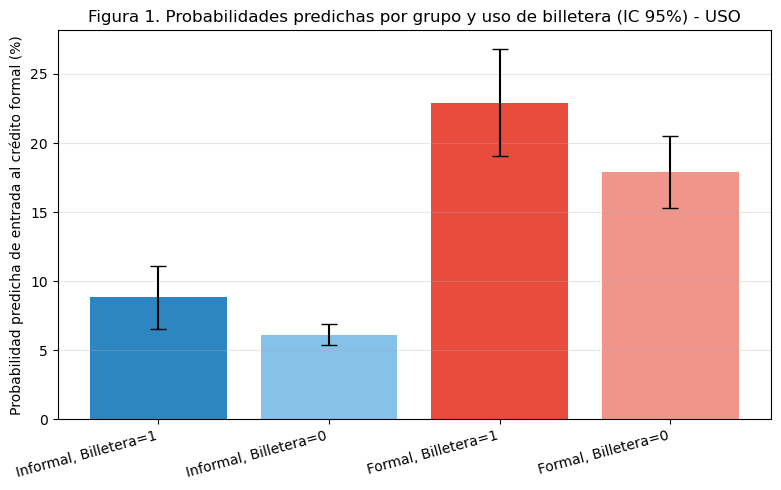


9. RESUMEN FINAL - USO DE BILLETERA

📊 ESTADÍSTICAS DESCRIPTIVAS
─────────────────────────────────────────────────────────────
  Total de observaciones:          6,358
  Usuarios de billetera (USO):     872 (13.72%)
  Tasa de nuevo crédito formal:    9.25%
  Tasa de informalidad:            79.05%

📊 RESULTADOS PRINCIPALES
─────────────────────────────────────────────────────────────
  EMP_informal (H1):               2.702 p.p. (p=0.0137)
  EMP_formal:                      5.007 p.p. (p=0.0357)
  Diferencia (informal - formal):  -2.305 p.p. (p=0.3808)
  EMD interacción (H2):            8.53 p.p.

📊 PROBABILIDADES CONDICIONALES
─────────────────────────────────────────────────────────────
  Informales con billetera:        14.73% (N=482)
  Informales sin billetera:        5.63% (N=4,544)
  Formales con billetera:          27.44% (N=390)
  Formales sin billetera:          16.35% (N=942)

📊 ARCHIVOS GENERADOS
─────────────────────────────────────────────────────────────
  📁 C:\Users\Daf

In [8]:
# =============================================================================
# CAPÍTULO II - ANÁLISIS METODOLÓGICO
# El efecto de las billeteras digitales en el acceso al crédito:
# un análisis de efectos heterogéneos según condición laboral en el Perú
# =============================================================================
# ESPECIFICACIÓN: USO DE BILLETERA (usa_billetera)
# =============================================================================
# AUTOR: [Tu nombre]
# FECHA: [Fecha actual]
# VERSIÓN: Final - Uso de billetera
# =============================================================================
# NOTA: Este código SOLO LEE la base ya construida.
# NO reconstruye nada desde los módulos del INEI.
# =============================================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt

# Configuración
pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)

# =============================================================================
# 0. CARGAR BASE DE DATOS
# =============================================================================
print("="*70)
print("CARGANDO BASE DE DATOS")
print("="*70)

ruta_base = r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\Base24_25\BASE_REGRESIONES.csv"
df = pd.read_csv(ruta_base, encoding="utf-8-sig")

print(f"✅ Base cargada: {len(df):,} observaciones")
print(f"✅ Variables: {len(df.columns)}")

# =============================================================================
# 1. VARIABLES DERIVADAS
# =============================================================================
print("\n" + "="*70)
print("1. CREANDO VARIABLES DERIVADAS")
print("="*70)

df['mujer'] = (df['sexo'] == 2).astype(int)
df['urbano'] = (df['estrato'] <= 6).astype(int)
df['edad_cuadrado'] = df['edad'] ** 2
df['interaccion'] = df['usa_billetera'] * df['trabajador_informal']

print("✅ Variables derivadas creadas")
print(f"   - mujer: {df['mujer'].sum():,} ({df['mujer'].mean():.1%})")
print(f"   - urbano: {df['urbano'].sum():,} ({df['urbano'].mean():.1%})")
print(f"   - edad_cuadrado: media {df['edad_cuadrado'].mean():.0f}")
print(f"   - interaccion (usa_billetera × informal): {df['interaccion'].sum():,} ({df['interaccion'].mean():.1%})")

# =============================================================================
# 2. TABLA C: USUARIOS VS NO USUARIOS (USO)
# =============================================================================
print("\n" + "="*70)
print("2. TABLA C. USUARIOS VS NO USUARIOS DE BILLETERA (USO)")
print("="*70)

vars_tabla = {
    'nuevo_credito_formal': 'Entrada al crédito formal (2025)',
    'trabajador_informal': 'Trabajador informal (2024)',
    'edad': 'Edad (2024)',
    'mujer': 'Mujer (2024)',
    'nivel_educativo': 'Nivel educativo (1-12) (2024)',
    'urbano': 'Urbano (2024)'
}

print(f"{'Variable':<35} | {'Usuarios':>10} | {'No usuarios':>12} | {'Dif.':>8} | {'Valor p':>8}")
print("-" * 75)

for var, label in vars_tabla.items():
    gu = df.loc[df['usa_billetera'] == 1, var].dropna()
    gn = df.loc[df['usa_billetera'] == 0, var].dropna()
    mu, mn = gu.mean(), gn.mean()
    diff = mu - mn
    t_stat, p_val = stats.ttest_ind(gu, gn, equal_var=False)
    sig = "***" if p_val < 0.01 else ("**" if p_val < 0.05 else ("*" if p_val < 0.10 else ""))
    print(f"{label:<35} | {mu:>10.4f} | {mn:>12.4f} | {diff:>+8.4f} | {p_val:>8.4f} {sig}")

n_usu = (df['usa_billetera'] == 1).sum()
n_nou = (df['usa_billetera'] == 0).sum()
print(f"\n{'N':<35} | {n_usu:>10,} | {n_nou:>12,} |")
print("=" * 75)

# =============================================================================
# 3. PROBABILIDADES CONDICIONALES (USO)
# =============================================================================
print("\n" + "="*70)
print("3. PROBABILIDADES CONDICIONALES (USO)")
print("="*70)

def prob(bill, inf):
    sub = df[(df['usa_billetera'] == bill) & (df['trabajador_informal'] == inf)]
    return sub['nuevo_credito_formal'].mean(), len(sub)

p1, n1 = prob(1, 1)  # Informales con billetera
p2, n2 = prob(0, 1)  # Informales sin billetera
p3, n3 = prob(1, 0)  # Formales con billetera
p4, n4 = prob(0, 0)  # Formales sin billetera

print(f"{'Grupo':<30} | {'Probabilidad':>12} | {'N':>8}")
print("-" * 55)
print(f"{'Informales, Billetera=1':<30} | {p1:>12.2%} | {n1:>8,}")
print(f"{'Informales, Billetera=0':<30} | {p2:>12.2%} | {n2:>8,}")
print(f"{'Formales, Billetera=1':<30} | {p3:>12.2%} | {n3:>8,}")
print(f"{'Formales, Billetera=0':<30} | {p4:>12.2%} | {n4:>8,}")
print("-" * 55)
print(f"{'Diferencia informales':<30} | {(p1-p2):>12.2%} |")
print(f"{'Diferencia formales':<30} | {(p3-p4):>12.2%} |")

# Guardar para potencia estadística
celdas = {
    'p1': p1, 'n1': n1,
    'p2': p2, 'n2': n2,
    'p3': p3, 'n3': n3,
    'p4': p4, 'n4': n4
}

# =============================================================================
# 4. MODELO PROBIT (USO)
# =============================================================================
print("\n" + "="*70)
print("4. MODELO PROBIT (USO)")
print("="*70)

vars_modelo = ['nuevo_credito_formal', 'usa_billetera', 'trabajador_informal', 
               'interaccion', 'edad', 'edad_cuadrado', 'mujer', 'nivel_educativo',
               'urbano', 'miembros_hogar', 'dominio', 'conglomerado']

df_modelo = df.dropna(subset=vars_modelo).copy().reset_index(drop=True)
print(f"N para el modelo: {len(df_modelo):,}")

Y = df_modelo['nuevo_credito_formal']
Xcols = ['usa_billetera', 'trabajador_informal', 'interaccion', 
         'edad', 'edad_cuadrado', 'mujer', 'nivel_educativo', 
         'urbano', 'miembros_hogar']

X = df_modelo[Xcols].astype(float)
X = pd.concat([X, pd.get_dummies(df_modelo['dominio'], prefix='DOM', drop_first=True, dtype=float)], axis=1)
X = sm.add_constant(X)

colnames = X.columns.tolist()

modelo = sm.Probit(Y, X).fit(disp=0, cov_type='cluster', cov_kwds={'groups': df_modelo['conglomerado'].values})

print("\nRESULTADOS DEL MODELO PROBIT (USO)")
print("="*70)
print(modelo.summary())

# =============================================================================
# 5. EFECTOS MARGINALES POR SUBGRUPO (USO)
# =============================================================================
print("\n" + "="*70)
print("5. EFECTOS MARGINALES POR SUBGRUPO (USO)")
print("="*70)

def calcular_emp_subgrupo(modelo, X, mask, informal_value, colnames):
    beta = modelo.params.values
    Xg = X.loc[mask].copy()
    
    X1 = Xg.copy()
    X1['usa_billetera'] = 1.0
    X1['interaccion'] = 1.0 * informal_value
    
    X0 = Xg.copy()
    X0['usa_billetera'] = 0.0
    X0['interaccion'] = 0.0 * informal_value
    
    X1v = X1[colnames].values.astype(float)
    X0v = X0[colnames].values.astype(float)
    
    idx1 = X1v @ beta
    idx0 = X0v @ beta
    
    emp = (stats.norm.cdf(idx1) - stats.norm.cdf(idx0)).mean()
    grad = (stats.norm.pdf(idx1)[:, None] * X1v - stats.norm.pdf(idx0)[:, None] * X0v).mean(axis=0)
    
    return emp, grad

def comparar_grupos(modelo, X, mask_a, mask_b, informal_a, informal_b, colnames, etiqueta_a, etiqueta_b):
    V = modelo.cov_params().values
    
    emp_a, grad_a = calcular_emp_subgrupo(modelo, X, mask_a, informal_a, colnames)
    emp_b, grad_b = calcular_emp_subgrupo(modelo, X, mask_b, informal_b, colnames)
    
    se_a = np.sqrt(grad_a @ V @ grad_a)
    se_b = np.sqrt(grad_b @ V @ grad_b)
    
    delta = emp_a - emp_b
    se_delta = np.sqrt(grad_a @ V @ grad_a + grad_b @ V @ grad_b - 2 * grad_a @ V @ grad_b)
    
    def zp(est, se):
        z = est / se if se > 0 else 0
        return z, 2 * (1 - stats.norm.cdf(abs(z)))
    
    z_a, p_a = zp(emp_a, se_a)
    z_b, p_b = zp(emp_b, se_b)
    z_d, p_d = zp(delta, se_delta)
    
    resumen = pd.DataFrame({
        'EMP_pp': [emp_a * 100, emp_b * 100, delta * 100],
        'SE_pp': [se_a * 100, se_b * 100, se_delta * 100],
        'IC95_low': [(emp_a - 1.96*se_a)*100, (emp_b - 1.96*se_b)*100, (delta - 1.96*se_delta)*100],
        'IC95_high': [(emp_a + 1.96*se_a)*100, (emp_b + 1.96*se_b)*100, (delta + 1.96*se_delta)*100],
        'p': [p_a, p_b, p_d],
        'N': [int(mask_a.sum()), int(mask_b.sum()), int(mask_a.sum() + mask_b.sum())]
    }, index=[etiqueta_a, etiqueta_b, f'Diferencia ({etiqueta_a} - {etiqueta_b})'])
    
    return resumen

mask_inf = (df_modelo['trabajador_informal'] == 1).values
mask_for = (df_modelo['trabajador_informal'] == 0).values

tabla_h1h2 = comparar_grupos(
    modelo, X, mask_inf, mask_for, 
    informal_a=1, informal_b=0,
    colnames=colnames,
    etiqueta_a='Trabajadores informales',
    etiqueta_b='Trabajadores formales'
)

print("\nTABLA D. RESULTADO PRINCIPAL (Contraste H1 y H2) - USO")
print("="*70)
print(tabla_h1h2.round(3))

# =============================================================================
# 6. PRUEBAS DE HIPÓTESIS (USO)
# =============================================================================
print("\n" + "="*70)
print("6. PRUEBAS DE HIPÓTESIS (USO)")
print("="*70)

emp_inf = tabla_h1h2.loc['Trabajadores informales', 'EMP_pp'] / 100
se_inf = tabla_h1h2.loc['Trabajadores informales', 'SE_pp'] / 100
p_inf = tabla_h1h2.loc['Trabajadores informales', 'p']

print(f"\nH1 (EMP_informal > 0):")
print(f"  EMP_informal = {emp_inf*100:.3f} p.p.")
print(f"  p (una cola) = {p_inf/2:.4f}")
print(f"  → {'✅ SE RESPALDA' if emp_inf > 0 and p_inf/2 < 0.05 else '❌ NO se respalda'}")

emp_for = tabla_h1h2.loc['Trabajadores formales', 'EMP_pp'] / 100
se_for = tabla_h1h2.loc['Trabajadores formales', 'SE_pp'] / 100
p_for = tabla_h1h2.loc['Trabajadores formales', 'p']

umbral = 0.02
t1 = (emp_for - umbral) / se_for if se_for > 0 else 0
t2 = (emp_for + umbral) / se_for if se_for > 0 else 0
p_tost = max(stats.norm.cdf(t1), 1 - stats.norm.cdf(t2))

print(f"\nH2 - TOST equivalencia de EMP_formal contra ±{umbral*100:.0f} p.p.:")
print(f"  EMP_formal = {emp_for*100:.3f} p.p.")
print(f"  p_TOST = {p_tost:.4f}")
print(f"  → {'✅ EQUIVALENTE (acotado)' if p_tost < 0.05 else '❌ NO se puede concluir equivalencia'}")

# =============================================================================
# 7. POTENCIA ESTADÍSTICA (USO)
# =============================================================================
print("\n" + "="*70)
print("7. POTENCIA ESTADÍSTICA Y EFECTO MÍNIMO DETECTABLE (USO)")
print("="*70)

z_alpha, z_beta = 1.96, 0.84
z_sum = z_alpha + z_beta

def emd_dos_celdas(pA, nA, pB, nB):
    vA = pA * (1 - pA) / nA
    vB = pB * (1 - pB) / nB
    return z_sum * np.sqrt(vA + vB), vA, vB

emd_inf, v1, v2 = emd_dos_celdas(celdas['p1'], celdas['n1'], celdas['p2'], celdas['n2'])
emd_for, v3, v4 = emd_dos_celdas(celdas['p3'], celdas['n3'], celdas['p4'], celdas['n4'])
emd_interaccion = z_sum * np.sqrt(v1 + v2 + v3 + v4)

print(f"{'Celda':<25} | {'N':>6} | {'Tasa base':>10} | {'EMD (p.p.)':>10}")
print("-" * 58)
print(f"{'Informal, billetera=1':<25} | {celdas['n1']:>6,} | {celdas['p1']*100:>9.2f}% |")
print(f"{'Informal, billetera=0':<25} | {celdas['n2']:>6,} | {celdas['p2']*100:>9.2f}% | {emd_inf*100:>9.2f}")
print(f"{'Formal, billetera=1':<25} | {celdas['n3']:>6,} | {celdas['p3']*100:>9.2f}% |")
print(f"{'Formal, billetera=0':<25} | {celdas['n4']:>6,} | {celdas['p4']*100:>9.2f}% | {emd_for*100:>9.2f}")
print("-" * 58)
print(f"{'Interacción (H2)':<25} | {'':>6} | {'':>10} | {emd_interaccion*100:>9.2f}")
print("=" * 58)

# =============================================================================
# 8. FIGURA 1: PROBABILIDADES PREDICHAS (USO)
# =============================================================================
print("\n" + "="*70)
print("8. FIGURA 1 - PROBABILIDADES PREDICHAS (USO)")
print("="*70)

def prob_predicha_subgrupo(modelo, X, mask, billetera_value, informal_value, colnames):
    beta = modelo.params.values
    Xg = X.loc[mask].copy()
    Xg['usa_billetera'] = float(billetera_value)
    Xg['interaccion'] = float(billetera_value) * float(informal_value)
    Xv = Xg[colnames].values.astype(float)
    idx = Xv @ beta
    prob = stats.norm.cdf(idx).mean()
    grad = (stats.norm.pdf(idx)[:, None] * Xv).mean(axis=0)
    return prob, grad

V = modelo.cov_params().values
combos = [
    ('Informal, Billetera=1', 1, mask_inf, 1),
    ('Informal, Billetera=0', 0, mask_inf, 1),
    ('Formal, Billetera=1', 1, mask_for, 0),
    ('Formal, Billetera=0', 0, mask_for, 0)
]

filas = []
for etiqueta, bill, mask, inf_val in combos:
    p, g = prob_predicha_subgrupo(modelo, X, mask, bill, inf_val, colnames)
    se = np.sqrt(g @ V @ g)
    filas.append({
        'Grupo': etiqueta,
        'Prob': p,
        'SE': se,
        'IC_low': max(p - 1.96*se, 0),
        'IC_high': min(p + 1.96*se, 1)
    })

df_fig1 = pd.DataFrame(filas)
print("\nProbabilidades predichas (USO):")
print(df_fig1.round(4))

fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(df_fig1))
err_low = (df_fig1['Prob'] - df_fig1['IC_low']) * 100
err_high = (df_fig1['IC_high'] - df_fig1['Prob']) * 100

bars = ax.bar(x, df_fig1['Prob'] * 100, yerr=[err_low, err_high], capsize=6,
              color=['#2E86C1', '#85C1E9', '#E74C3C', '#F1948A'])

ax.set_xticks(list(x))
ax.set_xticklabels(df_fig1['Grupo'], rotation=15, ha='right')
ax.set_ylabel('Probabilidad predicha de entrada al crédito formal (%)')
ax.set_title('Figura 1. Probabilidades predichas por grupo y uso de billetera (IC 95%) - USO')
ax.grid(axis='y', alpha=0.3)

ruta_figura = r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\Base24_25\figura1_uso.png"
plt.tight_layout()
plt.savefig(ruta_figura, dpi=150)
print(f"\n✅ Figura guardada: {ruta_figura}")
plt.show()

# =============================================================================
# 9. RESUMEN FINAL (USO)
# =============================================================================
print("\n" + "="*70)
print("9. RESUMEN FINAL - USO DE BILLETERA")
print("="*70)

p_diferencia = tabla_h1h2.loc['Diferencia (Trabajadores informales - Trabajadores formales)', 'p']

print(f"""
📊 ESTADÍSTICAS DESCRIPTIVAS
─────────────────────────────────────────────────────────────
  Total de observaciones:          {len(df):,}
  Usuarios de billetera (USO):     {df['usa_billetera'].sum():,} ({df['usa_billetera'].mean():.2%})
  Tasa de nuevo crédito formal:    {df['nuevo_credito_formal'].mean():.2%}
  Tasa de informalidad:            {df['trabajador_informal'].mean():.2%}

📊 RESULTADOS PRINCIPALES
─────────────────────────────────────────────────────────────
  EMP_informal (H1):               {emp_inf*100:.3f} p.p. (p={p_inf/2:.4f})
  EMP_formal:                      {emp_for*100:.3f} p.p. (p={p_for:.4f})
  Diferencia (informal - formal):  {(emp_inf-emp_for)*100:.3f} p.p. (p={p_diferencia:.4f})
  EMD interacción (H2):            {emd_interaccion*100:.2f} p.p.

📊 PROBABILIDADES CONDICIONALES
─────────────────────────────────────────────────────────────
  Informales con billetera:        {p1:.2%} (N={n1:,})
  Informales sin billetera:        {p2:.2%} (N={n2:,})
  Formales con billetera:          {p3:.2%} (N={n3:,})
  Formales sin billetera:          {p4:.2%} (N={n4:,})

📊 ARCHIVOS GENERADOS
─────────────────────────────────────────────────────────────
  📁 {ruta_base}
  📁 {ruta_figura}
""")

print("\n" + "="*70)
print("✅ PROCESO COMPLETADO EXITOSAMENTE - USO DE BILLETERA")
print("="*70)

CARGANDO BASE DE DATOS
✅ Base cargada: 6,358 observaciones
✅ Variables: 18

1. CREANDO VARIABLES DERIVADAS
✅ Variables derivadas creadas
   - mujer: 1,995 (31.4%)
   - urbano: 3,849 (60.5%)
   - edad_cuadrado: media 3004
   - interaccion (tiene_billetera × informal): 890.0 (14.0%)

2. TABLA C. USUARIOS VS NO USUARIOS DE BILLETERA (TENENCIA)
Variable                            |   Usuarios |  No usuarios |     Dif. |  Valor p
---------------------------------------------------------------------------
Entrada al crédito formal (2025)    |     0.1855 |       0.0639 |  +0.1216 |   0.0000 ***
Trabajador informal (2024)          |     0.5961 |       0.8502 |  -0.2540 |   0.0000 ***
Edad (2024)                         |    44.9745 |      55.2637 | -10.2892 |   0.0000 ***
Mujer (2024)                        |     0.3697 |       0.2966 |  +0.0731 |   0.0000 ***
Nivel educativo (1-12) (2024)       |     6.6457 |       4.5891 |  +2.0566 |   0.0000 ***
Urbano (2024)                       |     0.8

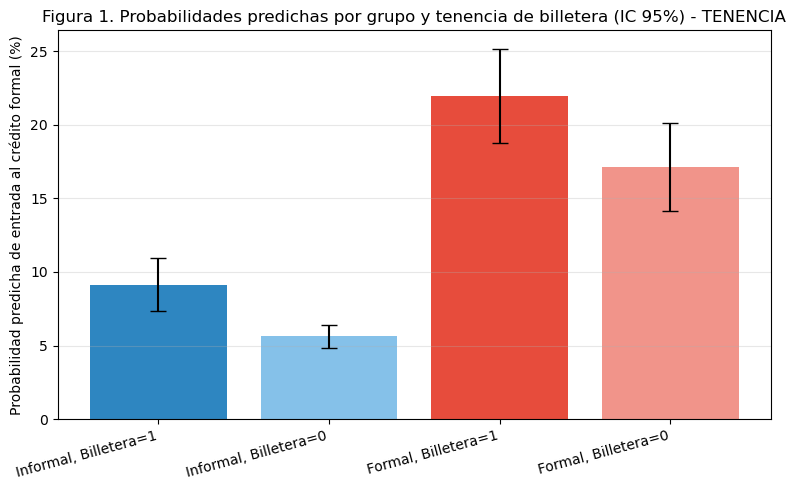


9. RESUMEN FINAL - TENENCIA DE BILLETERA

📊 ESTADÍSTICAS DESCRIPTIVAS
─────────────────────────────────────────────────────────────
  Total de observaciones:          6,358
  Usuarios de billetera (TENENCIA): 1,493 (23.48%)
  Tasa de nuevo crédito formal:    9.25%
  Tasa de informalidad:            79.05%

📊 RESULTADOS PRINCIPALES
─────────────────────────────────────────────────────────────
  EMP_informal (H1):               3.514 p.p. (p=0.0002)
  EMP_formal:                      4.816 p.p. (p=0.0330)
  Diferencia (informal - formal):  -1.302 p.p. (p=0.5865)
  EMD interacción (H2):            7.04 p.p.

📊 PROBABILIDADES CONDICIONALES
─────────────────────────────────────────────────────────────
  Informales con billetera:        13.82% (N=890)
  Informales sin billetera:        4.93% (N=4,136)
  Formales con billetera:          25.54% (N=603)
  Formales sin billetera:          14.68% (N=729)

📊 ARCHIVOS GENERADOS
─────────────────────────────────────────────────────────────
  📁 C:\U

In [9]:
# =============================================================================
# CAPÍTULO II - ANÁLISIS METODOLÓGICO
# El efecto de las billeteras digitales en el acceso al crédito:
# un análisis de efectos heterogéneos según condición laboral en el Perú
# =============================================================================
# ESPECIFICACIÓN: TENENCIA DE BILLETERA (tiene_billetera)
# =============================================================================
# AUTOR: [Tu nombre]
# FECHA: [Fecha actual]
# VERSIÓN: Final - Tenencia de billetera
# =============================================================================
# NOTA: Este código SOLO LEE la base ya construida.
# NO reconstruye nada desde los módulos del INEI.
# =============================================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt

# Configuración
pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)

# =============================================================================
# 0. CARGAR BASE DE DATOS
# =============================================================================
print("="*70)
print("CARGANDO BASE DE DATOS")
print("="*70)

ruta_base = r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\Base24_25\BASE_REGRESIONES.csv"
df = pd.read_csv(ruta_base, encoding="utf-8-sig")

print(f"✅ Base cargada: {len(df):,} observaciones")
print(f"✅ Variables: {len(df.columns)}")

# =============================================================================
# 1. VARIABLES DERIVADAS
# =============================================================================
print("\n" + "="*70)
print("1. CREANDO VARIABLES DERIVADAS")
print("="*70)

df['mujer'] = (df['sexo'] == 2).astype(int)
df['urbano'] = (df['estrato'] <= 6).astype(int)
df['edad_cuadrado'] = df['edad'] ** 2
df['interaccion'] = df['tiene_billetera'] * df['trabajador_informal']

print("✅ Variables derivadas creadas")
print(f"   - mujer: {df['mujer'].sum():,} ({df['mujer'].mean():.1%})")
print(f"   - urbano: {df['urbano'].sum():,} ({df['urbano'].mean():.1%})")
print(f"   - edad_cuadrado: media {df['edad_cuadrado'].mean():.0f}")
print(f"   - interaccion (tiene_billetera × informal): {df['interaccion'].sum():,} ({df['interaccion'].mean():.1%})")

# =============================================================================
# 2. TABLA C: USUARIOS VS NO USUARIOS (TENENCIA)
# =============================================================================
print("\n" + "="*70)
print("2. TABLA C. USUARIOS VS NO USUARIOS DE BILLETERA (TENENCIA)")
print("="*70)

vars_tabla = {
    'nuevo_credito_formal': 'Entrada al crédito formal (2025)',
    'trabajador_informal': 'Trabajador informal (2024)',
    'edad': 'Edad (2024)',
    'mujer': 'Mujer (2024)',
    'nivel_educativo': 'Nivel educativo (1-12) (2024)',
    'urbano': 'Urbano (2024)'
}

print(f"{'Variable':<35} | {'Usuarios':>10} | {'No usuarios':>12} | {'Dif.':>8} | {'Valor p':>8}")
print("-" * 75)

for var, label in vars_tabla.items():
    gu = df.loc[df['tiene_billetera'] == 1, var].dropna()
    gn = df.loc[df['tiene_billetera'] == 0, var].dropna()
    mu, mn = gu.mean(), gn.mean()
    diff = mu - mn
    t_stat, p_val = stats.ttest_ind(gu, gn, equal_var=False)
    sig = "***" if p_val < 0.01 else ("**" if p_val < 0.05 else ("*" if p_val < 0.10 else ""))
    print(f"{label:<35} | {mu:>10.4f} | {mn:>12.4f} | {diff:>+8.4f} | {p_val:>8.4f} {sig}")

n_usu = (df['tiene_billetera'] == 1).sum()
n_nou = (df['tiene_billetera'] == 0).sum()
print(f"\n{'N':<35} | {n_usu:>10,} | {n_nou:>12,} |")
print("=" * 75)

# =============================================================================
# 3. PROBABILIDADES CONDICIONALES (TENENCIA)
# =============================================================================
print("\n" + "="*70)
print("3. PROBABILIDADES CONDICIONALES (TENENCIA)")
print("="*70)

def prob(bill, inf):
    sub = df[(df['tiene_billetera'] == bill) & (df['trabajador_informal'] == inf)]
    return sub['nuevo_credito_formal'].mean(), len(sub)

p1, n1 = prob(1, 1)  # Informales con billetera
p2, n2 = prob(0, 1)  # Informales sin billetera
p3, n3 = prob(1, 0)  # Formales con billetera
p4, n4 = prob(0, 0)  # Formales sin billetera

print(f"{'Grupo':<30} | {'Probabilidad':>12} | {'N':>8}")
print("-" * 55)
print(f"{'Informales, Billetera=1':<30} | {p1:>12.2%} | {n1:>8,}")
print(f"{'Informales, Billetera=0':<30} | {p2:>12.2%} | {n2:>8,}")
print(f"{'Formales, Billetera=1':<30} | {p3:>12.2%} | {n3:>8,}")
print(f"{'Formales, Billetera=0':<30} | {p4:>12.2%} | {n4:>8,}")
print("-" * 55)
print(f"{'Diferencia informales':<30} | {(p1-p2):>12.2%} |")
print(f"{'Diferencia formales':<30} | {(p3-p4):>12.2%} |")

# Guardar para potencia estadística
celdas = {
    'p1': p1, 'n1': n1,
    'p2': p2, 'n2': n2,
    'p3': p3, 'n3': n3,
    'p4': p4, 'n4': n4
}

# =============================================================================
# 4. MODELO PROBIT (TENENCIA)
# =============================================================================
print("\n" + "="*70)
print("4. MODELO PROBIT (TENENCIA)")
print("="*70)

vars_modelo = ['nuevo_credito_formal', 'tiene_billetera', 'trabajador_informal', 
               'interaccion', 'edad', 'edad_cuadrado', 'mujer', 'nivel_educativo',
               'urbano', 'miembros_hogar', 'dominio', 'conglomerado']

df_modelo = df.dropna(subset=vars_modelo).copy().reset_index(drop=True)
print(f"N para el modelo: {len(df_modelo):,}")

Y = df_modelo['nuevo_credito_formal']
Xcols = ['tiene_billetera', 'trabajador_informal', 'interaccion', 
         'edad', 'edad_cuadrado', 'mujer', 'nivel_educativo', 
         'urbano', 'miembros_hogar']

X = df_modelo[Xcols].astype(float)
X = pd.concat([X, pd.get_dummies(df_modelo['dominio'], prefix='DOM', drop_first=True, dtype=float)], axis=1)
X = sm.add_constant(X)

colnames = X.columns.tolist()

modelo = sm.Probit(Y, X).fit(disp=0, cov_type='cluster', cov_kwds={'groups': df_modelo['conglomerado'].values})

print("\nRESULTADOS DEL MODELO PROBIT (TENENCIA)")
print("="*70)
print(modelo.summary())

# =============================================================================
# 5. EFECTOS MARGINALES POR SUBGRUPO (TENENCIA)
# =============================================================================
print("\n" + "="*70)
print("5. EFECTOS MARGINALES POR SUBGRUPO (TENENCIA)")
print("="*70)

def calcular_emp_subgrupo(modelo, X, mask, informal_value, colnames):
    beta = modelo.params.values
    Xg = X.loc[mask].copy()
    
    X1 = Xg.copy()
    X1['tiene_billetera'] = 1.0
    X1['interaccion'] = 1.0 * informal_value
    
    X0 = Xg.copy()
    X0['tiene_billetera'] = 0.0
    X0['interaccion'] = 0.0 * informal_value
    
    X1v = X1[colnames].values.astype(float)
    X0v = X0[colnames].values.astype(float)
    
    idx1 = X1v @ beta
    idx0 = X0v @ beta
    
    emp = (stats.norm.cdf(idx1) - stats.norm.cdf(idx0)).mean()
    grad = (stats.norm.pdf(idx1)[:, None] * X1v - stats.norm.pdf(idx0)[:, None] * X0v).mean(axis=0)
    
    return emp, grad

def comparar_grupos(modelo, X, mask_a, mask_b, informal_a, informal_b, colnames, etiqueta_a, etiqueta_b):
    V = modelo.cov_params().values
    
    emp_a, grad_a = calcular_emp_subgrupo(modelo, X, mask_a, informal_a, colnames)
    emp_b, grad_b = calcular_emp_subgrupo(modelo, X, mask_b, informal_b, colnames)
    
    se_a = np.sqrt(grad_a @ V @ grad_a)
    se_b = np.sqrt(grad_b @ V @ grad_b)
    
    delta = emp_a - emp_b
    se_delta = np.sqrt(grad_a @ V @ grad_a + grad_b @ V @ grad_b - 2 * grad_a @ V @ grad_b)
    
    def zp(est, se):
        z = est / se if se > 0 else 0
        return z, 2 * (1 - stats.norm.cdf(abs(z)))
    
    z_a, p_a = zp(emp_a, se_a)
    z_b, p_b = zp(emp_b, se_b)
    z_d, p_d = zp(delta, se_delta)
    
    resumen = pd.DataFrame({
        'EMP_pp': [emp_a * 100, emp_b * 100, delta * 100],
        'SE_pp': [se_a * 100, se_b * 100, se_delta * 100],
        'IC95_low': [(emp_a - 1.96*se_a)*100, (emp_b - 1.96*se_b)*100, (delta - 1.96*se_delta)*100],
        'IC95_high': [(emp_a + 1.96*se_a)*100, (emp_b + 1.96*se_b)*100, (delta + 1.96*se_delta)*100],
        'p': [p_a, p_b, p_d],
        'N': [int(mask_a.sum()), int(mask_b.sum()), int(mask_a.sum() + mask_b.sum())]
    }, index=[etiqueta_a, etiqueta_b, f'Diferencia ({etiqueta_a} - {etiqueta_b})'])
    
    return resumen

mask_inf = (df_modelo['trabajador_informal'] == 1).values
mask_for = (df_modelo['trabajador_informal'] == 0).values

tabla_h1h2 = comparar_grupos(
    modelo, X, mask_inf, mask_for, 
    informal_a=1, informal_b=0,
    colnames=colnames,
    etiqueta_a='Trabajadores informales',
    etiqueta_b='Trabajadores formales'
)

print("\nTABLA D. RESULTADO PRINCIPAL (Contraste H1 y H2) - TENENCIA")
print("="*70)
print(tabla_h1h2.round(3))

# =============================================================================
# 6. PRUEBAS DE HIPÓTESIS (TENENCIA)
# =============================================================================
print("\n" + "="*70)
print("6. PRUEBAS DE HIPÓTESIS (TENENCIA)")
print("="*70)

emp_inf = tabla_h1h2.loc['Trabajadores informales', 'EMP_pp'] / 100
se_inf = tabla_h1h2.loc['Trabajadores informales', 'SE_pp'] / 100
p_inf = tabla_h1h2.loc['Trabajadores informales', 'p']

print(f"\nH1 (EMP_informal > 0):")
print(f"  EMP_informal = {emp_inf*100:.3f} p.p.")
print(f"  p (una cola) = {p_inf/2:.4f}")
print(f"  → {'✅ SE RESPALDA' if emp_inf > 0 and p_inf/2 < 0.05 else '❌ NO se respalda'}")

emp_for = tabla_h1h2.loc['Trabajadores formales', 'EMP_pp'] / 100
se_for = tabla_h1h2.loc['Trabajadores formales', 'SE_pp'] / 100
p_for = tabla_h1h2.loc['Trabajadores formales', 'p']

umbral = 0.02
t1 = (emp_for - umbral) / se_for if se_for > 0 else 0
t2 = (emp_for + umbral) / se_for if se_for > 0 else 0
p_tost = max(stats.norm.cdf(t1), 1 - stats.norm.cdf(t2))

print(f"\nH2 - TOST equivalencia de EMP_formal contra ±{umbral*100:.0f} p.p.:")
print(f"  EMP_formal = {emp_for*100:.3f} p.p.")
print(f"  p_TOST = {p_tost:.4f}")
print(f"  → {'✅ EQUIVALENTE (acotado)' if p_tost < 0.05 else '❌ NO se puede concluir equivalencia'}")

# =============================================================================
# 7. POTENCIA ESTADÍSTICA (TENENCIA)
# =============================================================================
print("\n" + "="*70)
print("7. POTENCIA ESTADÍSTICA Y EFECTO MÍNIMO DETECTABLE (TENENCIA)")
print("="*70)

z_alpha, z_beta = 1.96, 0.84
z_sum = z_alpha + z_beta

def emd_dos_celdas(pA, nA, pB, nB):
    vA = pA * (1 - pA) / nA
    vB = pB * (1 - pB) / nB
    return z_sum * np.sqrt(vA + vB), vA, vB

emd_inf, v1, v2 = emd_dos_celdas(celdas['p1'], celdas['n1'], celdas['p2'], celdas['n2'])
emd_for, v3, v4 = emd_dos_celdas(celdas['p3'], celdas['n3'], celdas['p4'], celdas['n4'])
emd_interaccion = z_sum * np.sqrt(v1 + v2 + v3 + v4)

print(f"{'Celda':<25} | {'N':>6} | {'Tasa base':>10} | {'EMD (p.p.)':>10}")
print("-" * 58)
print(f"{'Informal, billetera=1':<25} | {celdas['n1']:>6,} | {celdas['p1']*100:>9.2f}% |")
print(f"{'Informal, billetera=0':<25} | {celdas['n2']:>6,} | {celdas['p2']*100:>9.2f}% | {emd_inf*100:>9.2f}")
print(f"{'Formal, billetera=1':<25} | {celdas['n3']:>6,} | {celdas['p3']*100:>9.2f}% |")
print(f"{'Formal, billetera=0':<25} | {celdas['n4']:>6,} | {celdas['p4']*100:>9.2f}% | {emd_for*100:>9.2f}")
print("-" * 58)
print(f"{'Interacción (H2)':<25} | {'':>6} | {'':>10} | {emd_interaccion*100:>9.2f}")
print("=" * 58)

# =============================================================================
# 8. FIGURA 1: PROBABILIDADES PREDICHAS (TENENCIA)
# =============================================================================
print("\n" + "="*70)
print("8. FIGURA 1 - PROBABILIDADES PREDICHAS (TENENCIA)")
print("="*70)

def prob_predicha_subgrupo(modelo, X, mask, billetera_value, informal_value, colnames):
    beta = modelo.params.values
    Xg = X.loc[mask].copy()
    Xg['tiene_billetera'] = float(billetera_value)
    Xg['interaccion'] = float(billetera_value) * float(informal_value)
    Xv = Xg[colnames].values.astype(float)
    idx = Xv @ beta
    prob = stats.norm.cdf(idx).mean()
    grad = (stats.norm.pdf(idx)[:, None] * Xv).mean(axis=0)
    return prob, grad

V = modelo.cov_params().values
combos = [
    ('Informal, Billetera=1', 1, mask_inf, 1),
    ('Informal, Billetera=0', 0, mask_inf, 1),
    ('Formal, Billetera=1', 1, mask_for, 0),
    ('Formal, Billetera=0', 0, mask_for, 0)
]

filas = []
for etiqueta, bill, mask, inf_val in combos:
    p, g = prob_predicha_subgrupo(modelo, X, mask, bill, inf_val, colnames)
    se = np.sqrt(g @ V @ g)
    filas.append({
        'Grupo': etiqueta,
        'Prob': p,
        'SE': se,
        'IC_low': max(p - 1.96*se, 0),
        'IC_high': min(p + 1.96*se, 1)
    })

df_fig1 = pd.DataFrame(filas)
print("\nProbabilidades predichas (TENENCIA):")
print(df_fig1.round(4))

fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(df_fig1))
err_low = (df_fig1['Prob'] - df_fig1['IC_low']) * 100
err_high = (df_fig1['IC_high'] - df_fig1['Prob']) * 100

bars = ax.bar(x, df_fig1['Prob'] * 100, yerr=[err_low, err_high], capsize=6,
              color=['#2E86C1', '#85C1E9', '#E74C3C', '#F1948A'])

ax.set_xticks(list(x))
ax.set_xticklabels(df_fig1['Grupo'], rotation=15, ha='right')
ax.set_ylabel('Probabilidad predicha de entrada al crédito formal (%)')
ax.set_title('Figura 1. Probabilidades predichas por grupo y tenencia de billetera (IC 95%) - TENENCIA')
ax.grid(axis='y', alpha=0.3)

ruta_figura = r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\Base24_25\figura1_tenencia.png"
plt.tight_layout()
plt.savefig(ruta_figura, dpi=150)
print(f"\n✅ Figura guardada: {ruta_figura}")
plt.show()

# =============================================================================
# 9. RESUMEN FINAL (TENENCIA)
# =============================================================================
print("\n" + "="*70)
print("9. RESUMEN FINAL - TENENCIA DE BILLETERA")
print("="*70)

p_diferencia = tabla_h1h2.loc['Diferencia (Trabajadores informales - Trabajadores formales)', 'p']

print(f"""
📊 ESTADÍSTICAS DESCRIPTIVAS
─────────────────────────────────────────────────────────────
  Total de observaciones:          {len(df):,}
  Usuarios de billetera (TENENCIA): {df['tiene_billetera'].sum():,} ({df['tiene_billetera'].mean():.2%})
  Tasa de nuevo crédito formal:    {df['nuevo_credito_formal'].mean():.2%}
  Tasa de informalidad:            {df['trabajador_informal'].mean():.2%}

📊 RESULTADOS PRINCIPALES
─────────────────────────────────────────────────────────────
  EMP_informal (H1):               {emp_inf*100:.3f} p.p. (p={p_inf/2:.4f})
  EMP_formal:                      {emp_for*100:.3f} p.p. (p={p_for:.4f})
  Diferencia (informal - formal):  {(emp_inf-emp_for)*100:.3f} p.p. (p={p_diferencia:.4f})
  EMD interacción (H2):            {emd_interaccion*100:.2f} p.p.

📊 PROBABILIDADES CONDICIONALES
─────────────────────────────────────────────────────────────
  Informales con billetera:        {p1:.2%} (N={n1:,})
  Informales sin billetera:        {p2:.2%} (N={n2:,})
  Formales con billetera:          {p3:.2%} (N={n3:,})
  Formales sin billetera:          {p4:.2%} (N={n4:,})

📊 ARCHIVOS GENERADOS
─────────────────────────────────────────────────────────────
  📁 {ruta_base}
  📁 {ruta_figura}
""")

print("\n" + "="*70)
print("✅ PROCESO COMPLETADO EXITOSAMENTE - TENENCIA DE BILLETERA")
print("="*70)

CARGANDO BASE DE DATOS
✅ Base cargada: 6,358 observaciones
✅ Variables: 18

1. CREANDO VARIABLES DERIVADAS
✅ Variables derivadas creadas
   - mujer: 1,995 (31.4%)
   - urbano: 3,849 (60.5%)
   - edad_cuadrado: media 3004
   - interaccion (usa_billetera × informal): 482.0 (7.6%)

2. TABLA C. USUARIOS VS NO USUARIOS DE BILLETERA (USO)
Variable                            |   Usuarios |  No usuarios |     Dif. |  Valor p
---------------------------------------------------------------------------
Entrada al crédito formal (2025)    |     0.2041 |       0.0747 |  +0.1294 |   0.0000 ***
Trabajador informal (2024)          |     0.5528 |       0.8283 |  -0.2755 |   0.0000 ***
Edad (2024)                         |    42.8440 |      54.4377 | -11.5936 |   0.0000 ***
Mujer (2024)                        |     0.3888 |       0.3019 |  +0.0869 |   0.0000 ***
Nivel educativo (1-12) (2024)       |     6.8647 |       4.7871 |  +2.0776 |   0.0000 ***
Urbano (2024)                       |     0.9025 |   

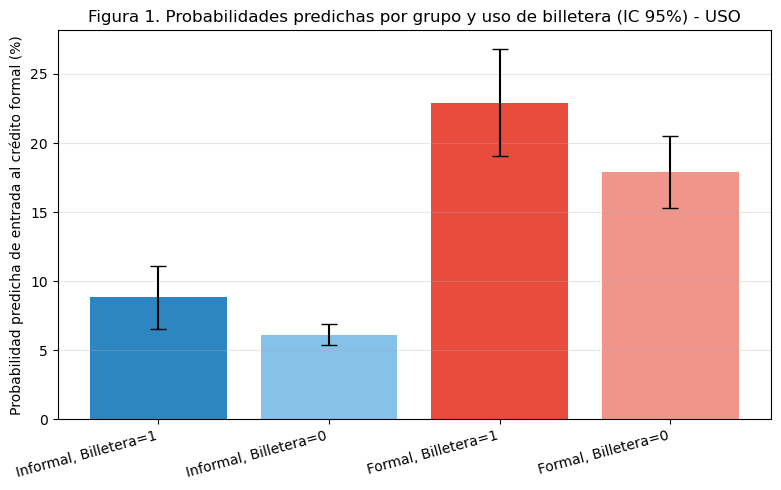


9. RESUMEN FINAL - USO DE BILLETERA

📊 ESTADÍSTICAS DESCRIPTIVAS
─────────────────────────────────────────────────────────────
  Total de observaciones:          6,358
  Usuarios de billetera (USO):     872 (13.72%)
  Tasa de nuevo crédito formal:    9.25%
  Tasa de informalidad:            79.05%

📊 RESULTADOS PRINCIPALES
─────────────────────────────────────────────────────────────
  EMP_informal (H1):               2.702 p.p. (p=0.0137)
  EMP_formal:                      5.007 p.p. (p=0.0357)
  Diferencia (informal - formal):  -2.305 p.p. (p=0.3808)
  EMD interacción (H2):            8.53 p.p.

📊 PROBABILIDADES CONDICIONALES
─────────────────────────────────────────────────────────────
  Informales con billetera:        14.73% (N=482)
  Informales sin billetera:        5.63% (N=4,544)
  Formales con billetera:          27.44% (N=390)
  Formales sin billetera:          16.35% (N=942)

📊 ARCHIVOS GENERADOS
─────────────────────────────────────────────────────────────
  📁 C:\Users\Daf

In [10]:
# =============================================================================
# CAPÍTULO II - ANÁLISIS METODOLÓGICO
# El efecto de las billeteras digitales en el acceso al crédito:
# un análisis de efectos heterogéneos según condición laboral en el Perú
# =============================================================================
# ESPECIFICACIÓN: USO DE BILLETERA (usa_billetera) - CORREGIDO
# =============================================================================
# CORRECCIONES APLICADAS:
# 1. Uso de billetera: P558H*_5 con valor == 5 (NO P558H*_7 con valor == 7)
# 2. Crédito formal: P558E1_4 = "Tarjeta de crédito", P558E1_9 = "Préstamo"
# 3. Nivel educativo: Excluido código 99 = Missing
# =============================================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt

# Configuración
pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)

# =============================================================================
# 0. CARGAR BASE DE DATOS
# =============================================================================
print("="*70)
print("CARGANDO BASE DE DATOS")
print("="*70)

ruta_base = r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\Base24_25\BASE_REGRESIONES.csv"
df = pd.read_csv(ruta_base, encoding="utf-8-sig")

print(f"✅ Base cargada: {len(df):,} observaciones")
print(f"✅ Variables: {len(df.columns)}")

# =============================================================================
# 1. VARIABLES DERIVADAS
# =============================================================================
print("\n" + "="*70)
print("1. CREANDO VARIABLES DERIVADAS")
print("="*70)

df['mujer'] = (df['sexo'] == 2).astype(int)
df['urbano'] = (df['estrato'] <= 6).astype(int)
df['edad_cuadrado'] = df['edad'] ** 2
df['interaccion'] = df['usa_billetera'] * df['trabajador_informal']

print("✅ Variables derivadas creadas")
print(f"   - mujer: {df['mujer'].sum():,} ({df['mujer'].mean():.1%})")
print(f"   - urbano: {df['urbano'].sum():,} ({df['urbano'].mean():.1%})")
print(f"   - edad_cuadrado: media {df['edad_cuadrado'].mean():.0f}")
print(f"   - interaccion (usa_billetera × informal): {df['interaccion'].sum():,} ({df['interaccion'].mean():.1%})")

# =============================================================================
# 2. TABLA C: USUARIOS VS NO USUARIOS (USO)
# =============================================================================
print("\n" + "="*70)
print("2. TABLA C. USUARIOS VS NO USUARIOS DE BILLETERA (USO)")
print("="*70)

vars_tabla = {
    'nuevo_credito_formal': 'Entrada al crédito formal (2025)',
    'trabajador_informal': 'Trabajador informal (2024)',
    'edad': 'Edad (2024)',
    'mujer': 'Mujer (2024)',
    'nivel_educativo': 'Nivel educativo (1-12) (2024)',
    'urbano': 'Urbano (2024)'
}

print(f"{'Variable':<35} | {'Usuarios':>10} | {'No usuarios':>12} | {'Dif.':>8} | {'Valor p':>8}")
print("-" * 75)

for var, label in vars_tabla.items():
    gu = df.loc[df['usa_billetera'] == 1, var].dropna()
    gn = df.loc[df['usa_billetera'] == 0, var].dropna()
    mu, mn = gu.mean(), gn.mean()
    diff = mu - mn
    t_stat, p_val = stats.ttest_ind(gu, gn, equal_var=False)
    sig = "***" if p_val < 0.01 else ("**" if p_val < 0.05 else ("*" if p_val < 0.10 else ""))
    print(f"{label:<35} | {mu:>10.4f} | {mn:>12.4f} | {diff:>+8.4f} | {p_val:>8.4f} {sig}")

n_usu = (df['usa_billetera'] == 1).sum()
n_nou = (df['usa_billetera'] == 0).sum()
print(f"\n{'N':<35} | {n_usu:>10,} | {n_nou:>12,} |")
print("=" * 75)

# =============================================================================
# 3. PROBABILIDADES CONDICIONALES (USO)
# =============================================================================
print("\n" + "="*70)
print("3. PROBABILIDADES CONDICIONALES (USO)")
print("="*70)

def prob(bill, inf):
    sub = df[(df['usa_billetera'] == bill) & (df['trabajador_informal'] == inf)]
    return sub['nuevo_credito_formal'].mean(), len(sub)

p1, n1 = prob(1, 1)  # Informales con billetera
p2, n2 = prob(0, 1)  # Informales sin billetera
p3, n3 = prob(1, 0)  # Formales con billetera
p4, n4 = prob(0, 0)  # Formales sin billetera

print(f"{'Grupo':<30} | {'Probabilidad':>12} | {'N':>8}")
print("-" * 55)
print(f"{'Informales, Billetera=1':<30} | {p1:>12.2%} | {n1:>8,}")
print(f"{'Informales, Billetera=0':<30} | {p2:>12.2%} | {n2:>8,}")
print(f"{'Formales, Billetera=1':<30} | {p3:>12.2%} | {n3:>8,}")
print(f"{'Formales, Billetera=0':<30} | {p4:>12.2%} | {n4:>8,}")
print("-" * 55)
print(f"{'Diferencia informales':<30} | {(p1-p2):>12.2%} |")
print(f"{'Diferencia formales':<30} | {(p3-p4):>12.2%} |")

# Guardar para potencia estadística
celdas = {
    'p1': p1, 'n1': n1,
    'p2': p2, 'n2': n2,
    'p3': p3, 'n3': n3,
    'p4': p4, 'n4': n4
}

# =============================================================================
# 4. MODELO PROBIT (USO)
# =============================================================================
print("\n" + "="*70)
print("4. MODELO PROBIT (USO)")
print("="*70)

vars_modelo = ['nuevo_credito_formal', 'usa_billetera', 'trabajador_informal', 
               'interaccion', 'edad', 'edad_cuadrado', 'mujer', 'nivel_educativo',
               'urbano', 'miembros_hogar', 'dominio', 'conglomerado']

df_modelo = df.dropna(subset=vars_modelo).copy().reset_index(drop=True)
print(f"N para el modelo: {len(df_modelo):,}")

Y = df_modelo['nuevo_credito_formal']
Xcols = ['usa_billetera', 'trabajador_informal', 'interaccion', 
         'edad', 'edad_cuadrado', 'mujer', 'nivel_educativo', 
         'urbano', 'miembros_hogar']

X = df_modelo[Xcols].astype(float)
X = pd.concat([X, pd.get_dummies(df_modelo['dominio'], prefix='DOM', drop_first=True, dtype=float)], axis=1)
X = sm.add_constant(X)

colnames = X.columns.tolist()

modelo = sm.Probit(Y, X).fit(disp=0, cov_type='cluster', cov_kwds={'groups': df_modelo['conglomerado'].values})

print("\nRESULTADOS DEL MODELO PROBIT (USO)")
print("="*70)
print(modelo.summary())

# =============================================================================
# 5. EFECTOS MARGINALES POR SUBGRUPO (USO)
# =============================================================================
print("\n" + "="*70)
print("5. EFECTOS MARGINALES POR SUBGRUPO (USO)")
print("="*70)

def calcular_emp_subgrupo(modelo, X, mask, informal_value, colnames):
    beta = modelo.params.values
    Xg = X.loc[mask].copy()
    
    X1 = Xg.copy()
    X1['usa_billetera'] = 1.0
    X1['interaccion'] = 1.0 * informal_value
    
    X0 = Xg.copy()
    X0['usa_billetera'] = 0.0
    X0['interaccion'] = 0.0 * informal_value
    
    X1v = X1[colnames].values.astype(float)
    X0v = X0[colnames].values.astype(float)
    
    idx1 = X1v @ beta
    idx0 = X0v @ beta
    
    emp = (stats.norm.cdf(idx1) - stats.norm.cdf(idx0)).mean()
    grad = (stats.norm.pdf(idx1)[:, None] * X1v - stats.norm.pdf(idx0)[:, None] * X0v).mean(axis=0)
    
    return emp, grad

def comparar_grupos(modelo, X, mask_a, mask_b, informal_a, informal_b, colnames, etiqueta_a, etiqueta_b):
    V = modelo.cov_params().values
    
    emp_a, grad_a = calcular_emp_subgrupo(modelo, X, mask_a, informal_a, colnames)
    emp_b, grad_b = calcular_emp_subgrupo(modelo, X, mask_b, informal_b, colnames)
    
    se_a = np.sqrt(grad_a @ V @ grad_a)
    se_b = np.sqrt(grad_b @ V @ grad_b)
    
    delta = emp_a - emp_b
    se_delta = np.sqrt(grad_a @ V @ grad_a + grad_b @ V @ grad_b - 2 * grad_a @ V @ grad_b)
    
    def zp(est, se):
        z = est / se if se > 0 else 0
        return z, 2 * (1 - stats.norm.cdf(abs(z)))
    
    z_a, p_a = zp(emp_a, se_a)
    z_b, p_b = zp(emp_b, se_b)
    z_d, p_d = zp(delta, se_delta)
    
    resumen = pd.DataFrame({
        'EMP_pp': [emp_a * 100, emp_b * 100, delta * 100],
        'SE_pp': [se_a * 100, se_b * 100, se_delta * 100],
        'IC95_low': [(emp_a - 1.96*se_a)*100, (emp_b - 1.96*se_b)*100, (delta - 1.96*se_delta)*100],
        'IC95_high': [(emp_a + 1.96*se_a)*100, (emp_b + 1.96*se_b)*100, (delta + 1.96*se_delta)*100],
        'p': [p_a, p_b, p_d],
        'N': [int(mask_a.sum()), int(mask_b.sum()), int(mask_a.sum() + mask_b.sum())]
    }, index=[etiqueta_a, etiqueta_b, f'Diferencia ({etiqueta_a} - {etiqueta_b})'])
    
    return resumen

mask_inf = (df_modelo['trabajador_informal'] == 1).values
mask_for = (df_modelo['trabajador_informal'] == 0).values

tabla_h1h2 = comparar_grupos(
    modelo, X, mask_inf, mask_for, 
    informal_a=1, informal_b=0,
    colnames=colnames,
    etiqueta_a='Trabajadores informales',
    etiqueta_b='Trabajadores formales'
)

print("\nTABLA D. RESULTADO PRINCIPAL (Contraste H1 y H2) - USO")
print("="*70)
print(tabla_h1h2.round(3))

# =============================================================================
# 6. PRUEBAS DE HIPÓTESIS (USO)
# =============================================================================
print("\n" + "="*70)
print("6. PRUEBAS DE HIPÓTESIS (USO)")
print("="*70)

emp_inf = tabla_h1h2.loc['Trabajadores informales', 'EMP_pp'] / 100
se_inf = tabla_h1h2.loc['Trabajadores informales', 'SE_pp'] / 100
p_inf = tabla_h1h2.loc['Trabajadores informales', 'p']

print(f"\nH1 (EMP_informal > 0):")
print(f"  EMP_informal = {emp_inf*100:.3f} p.p.")
print(f"  p (una cola) = {p_inf/2:.4f}")
print(f"  → {'✅ SE RESPALDA' if emp_inf > 0 and p_inf/2 < 0.05 else '❌ NO se respalda'}")

emp_for = tabla_h1h2.loc['Trabajadores formales', 'EMP_pp'] / 100
se_for = tabla_h1h2.loc['Trabajadores formales', 'SE_pp'] / 100
p_for = tabla_h1h2.loc['Trabajadores formales', 'p']

umbral = 0.02
t1 = (emp_for - umbral) / se_for if se_for > 0 else 0
t2 = (emp_for + umbral) / se_for if se_for > 0 else 0
p_tost = max(stats.norm.cdf(t1), 1 - stats.norm.cdf(t2))

print(f"\nH2 - TOST equivalencia de EMP_formal contra ±{umbral*100:.0f} p.p.:")
print(f"  EMP_formal = {emp_for*100:.3f} p.p.")
print(f"  p_TOST = {p_tost:.4f}")
print(f"  → {'✅ EQUIVALENTE (acotado)' if p_tost < 0.05 else '❌ NO se puede concluir equivalencia'}")

# =============================================================================
# 7. POTENCIA ESTADÍSTICA (USO)
# =============================================================================
print("\n" + "="*70)
print("7. POTENCIA ESTADÍSTICA Y EFECTO MÍNIMO DETECTABLE (USO)")
print("="*70)

z_alpha, z_beta = 1.96, 0.84
z_sum = z_alpha + z_beta

def emd_dos_celdas(pA, nA, pB, nB):
    vA = pA * (1 - pA) / nA
    vB = pB * (1 - pB) / nB
    return z_sum * np.sqrt(vA + vB), vA, vB

emd_inf, v1, v2 = emd_dos_celdas(celdas['p1'], celdas['n1'], celdas['p2'], celdas['n2'])
emd_for, v3, v4 = emd_dos_celdas(celdas['p3'], celdas['n3'], celdas['p4'], celdas['n4'])
emd_interaccion = z_sum * np.sqrt(v1 + v2 + v3 + v4)

print(f"{'Celda':<25} | {'N':>6} | {'Tasa base':>10} | {'EMD (p.p.)':>10}")
print("-" * 58)
print(f"{'Informal, billetera=1':<25} | {celdas['n1']:>6,} | {celdas['p1']*100:>9.2f}% |")
print(f"{'Informal, billetera=0':<25} | {celdas['n2']:>6,} | {celdas['p2']*100:>9.2f}% | {emd_inf*100:>9.2f}")
print(f"{'Formal, billetera=1':<25} | {celdas['n3']:>6,} | {celdas['p3']*100:>9.2f}% |")
print(f"{'Formal, billetera=0':<25} | {celdas['n4']:>6,} | {celdas['p4']*100:>9.2f}% | {emd_for*100:>9.2f}")
print("-" * 58)
print(f"{'Interacción (H2)':<25} | {'':>6} | {'':>10} | {emd_interaccion*100:>9.2f}")
print("=" * 58)

# =============================================================================
# 8. FIGURA 1: PROBABILIDADES PREDICHAS (USO)
# =============================================================================
print("\n" + "="*70)
print("8. FIGURA 1 - PROBABILIDADES PREDICHAS (USO)")
print("="*70)

def prob_predicha_subgrupo(modelo, X, mask, billetera_value, informal_value, colnames):
    beta = modelo.params.values
    Xg = X.loc[mask].copy()
    Xg['usa_billetera'] = float(billetera_value)
    Xg['interaccion'] = float(billetera_value) * float(informal_value)
    Xv = Xg[colnames].values.astype(float)
    idx = Xv @ beta
    prob = stats.norm.cdf(idx).mean()
    grad = (stats.norm.pdf(idx)[:, None] * Xv).mean(axis=0)
    return prob, grad

V = modelo.cov_params().values
combos = [
    ('Informal, Billetera=1', 1, mask_inf, 1),
    ('Informal, Billetera=0', 0, mask_inf, 1),
    ('Formal, Billetera=1', 1, mask_for, 0),
    ('Formal, Billetera=0', 0, mask_for, 0)
]

filas = []
for etiqueta, bill, mask, inf_val in combos:
    p, g = prob_predicha_subgrupo(modelo, X, mask, bill, inf_val, colnames)
    se = np.sqrt(g @ V @ g)
    filas.append({
        'Grupo': etiqueta,
        'Prob': p,
        'SE': se,
        'IC_low': max(p - 1.96*se, 0),
        'IC_high': min(p + 1.96*se, 1)
    })

df_fig1 = pd.DataFrame(filas)
print("\nProbabilidades predichas (USO):")
print(df_fig1.round(4))

fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(df_fig1))
err_low = (df_fig1['Prob'] - df_fig1['IC_low']) * 100
err_high = (df_fig1['IC_high'] - df_fig1['Prob']) * 100

bars = ax.bar(x, df_fig1['Prob'] * 100, yerr=[err_low, err_high], capsize=6,
              color=['#2E86C1', '#85C1E9', '#E74C3C', '#F1948A'])

ax.set_xticks(list(x))
ax.set_xticklabels(df_fig1['Grupo'], rotation=15, ha='right')
ax.set_ylabel('Probabilidad predicha de entrada al crédito formal (%)')
ax.set_title('Figura 1. Probabilidades predichas por grupo y uso de billetera (IC 95%) - USO')
ax.grid(axis='y', alpha=0.3)

ruta_figura = r"C:\Users\Dafne\Documents\GitHub\Base-de-datos-investigacion-Economica\Base24_25\figura1_uso.png"
plt.tight_layout()
plt.savefig(ruta_figura, dpi=150)
print(f"\n✅ Figura guardada: {ruta_figura}")
plt.show()

# =============================================================================
# 9. RESUMEN FINAL (USO)
# =============================================================================
print("\n" + "="*70)
print("9. RESUMEN FINAL - USO DE BILLETERA")
print("="*70)

p_diferencia = tabla_h1h2.loc['Diferencia (Trabajadores informales - Trabajadores formales)', 'p']

print(f"""
📊 ESTADÍSTICAS DESCRIPTIVAS
─────────────────────────────────────────────────────────────
  Total de observaciones:          {len(df):,}
  Usuarios de billetera (USO):     {df['usa_billetera'].sum():,} ({df['usa_billetera'].mean():.2%})
  Tasa de nuevo crédito formal:    {df['nuevo_credito_formal'].mean():.2%}
  Tasa de informalidad:            {df['trabajador_informal'].mean():.2%}

📊 RESULTADOS PRINCIPALES
─────────────────────────────────────────────────────────────
  EMP_informal (H1):               {emp_inf*100:.3f} p.p. (p={p_inf/2:.4f})
  EMP_formal:                      {emp_for*100:.3f} p.p. (p={p_for:.4f})
  Diferencia (informal - formal):  {(emp_inf-emp_for)*100:.3f} p.p. (p={p_diferencia:.4f})
  EMD interacción (H2):            {emd_interaccion*100:.2f} p.p.

📊 PROBABILIDADES CONDICIONALES
─────────────────────────────────────────────────────────────
  Informales con billetera:        {p1:.2%} (N={n1:,})
  Informales sin billetera:        {p2:.2%} (N={n2:,})
  Formales con billetera:          {p3:.2%} (N={n3:,})
  Formales sin billetera:          {p4:.2%} (N={n4:,})

📊 ARCHIVOS GENERADOS
─────────────────────────────────────────────────────────────
  📁 {ruta_base}
  📁 {ruta_figura}
""")

print("\n" + "="*70)
print("✅ PROCESO COMPLETADO EXITOSAMENTE - USO DE BILLETERA")
print("="*70)